# Cube-Quadruple Horizon Subgoal Proposer

Train a horizon-conditioned subgoal proposer for `cube-quadruple-play-v0` using the shared implementation in `agents/goal_proposer.py`. This notebook only handles cube-specific configuration, training, and visualization.

In [1]:
from __future__ import annotations

import os
from pathlib import Path

os.environ.setdefault('JAX_PLATFORMS', 'cpu')

import jax
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import trange

from agents.goal_proposer import (
    GCFlowGoalProposerAgent,
    GoalProposerCGCDataset,
    make_goal_proposer_config,
)
from utils.flax_utils import save_agent
from wrappers.datafuncs_utils import make_env_and_datasets, to_oracle_reps


/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


In [2]:
base_config = dict(
    env_name='cube-quadruple-play-oraclerep-v0',
    dataset_path='../../scratch/data/cube-quadruple-play-v0/cube-quadruple-play-v0.npz',
    observations_key='oracle_reps',
    goal_key='actor_goals',
    hidden_dims=(256, 256, 256),
    layer_norm=True,
    lr=3e-4,
    flow_steps=10,
    discount=0.995,
    backup_horizon=25,
    seed=0,
)

config = make_goal_proposer_config(
    'cube_quadruple_horizon_subgoal_proposer',
    observation_conditioned=True,
    horizon_conditioned=True,
    base_config=base_config,
)
config.update(
    batch_size=256,
    num_train_steps=50_000,
    log_interval=500,
    min_horizon_steps=1,
    max_horizon_steps=250,
    subgoal_steps=250,
    horizon_scale=250.0,
    output_dir='checkpoints/cube_quadruple_horizon_subgoal_proposer',
)
config

{'env_name': 'cube-quadruple-play-oraclerep-v0',
 'dataset_path': '../../scratch/data/cube-quadruple-play-v0/cube-quadruple-play-v0.npz',
 'observations_key': 'oracle_reps',
 'goal_key': 'actor_goals',
 'hidden_dims': (256, 256, 256),
 'layer_norm': True,
 'lr': 0.0003,
 'flow_steps': 10,
 'discount': 0.995,
 'backup_horizon': 25,
 'seed': 0,
 'output_dir': 'checkpoints/cube_quadruple_horizon_subgoal_proposer',
 'num_train_steps': 50000,
 'batch_size': 256,
 'log_interval': 500,
 'actions_key': 'low_actor_goals',
 'value_p_curgoal': 0.0,
 'value_p_trajgoal': 1.0,
 'value_p_randomgoal': 0.0,
 'value_geom_sample': False,
 'actor_p_curgoal': 0.0,
 'actor_p_trajgoal': 1.0,
 'actor_p_randomgoal': 0.0,
 'actor_geom_sample': True,
 'gc_negative': False,
 'goal_conditioned': False,
 'observation_conditioned': True,
 'horizon_conditioned': True,
 'horizon_key': 'horizons',
 'min_horizon_steps': 1,
 'max_horizon_steps': 250,
 'subgoal_steps': 250,
 'horizon_scale': 250.0}

`GoalProposerCGCDataset` handles the horizon-conditioned relabeling: it samples a transition index `i`, draws a horizon `n`, and trains against the oracle representation at `min(i + n, episode_end)`. For this environment, the oracle representation is the concatenated xyz positions of the 4 cubes.

In [3]:
env, base_train_dataset, val_dataset = make_env_and_datasets(
    config['env_name'],
    dataset_path=base_config['dataset_path'],
    use_oracle_reps=True,
)
train_dataset = GoalProposerCGCDataset(base_train_dataset, config=config)

example_batch = train_dataset.sample(config['batch_size'])
num_cubes = int(env.unwrapped._num_cubes)

print('env:', env.spec.id)
print('num_cubes:', num_cubes)
print('dataset keys:', sorted(base_train_dataset.keys()))
print('example batch keys:', sorted(example_batch.keys()))
print('observations:', example_batch[config['observations_key']].shape)
print('target subgoals:', example_batch[config['actions_key']].shape)
print('horizons:', example_batch[config['horizon_key']].shape)
print('horizon range:', float(example_batch[config['horizon_key']].min()), float(example_batch[config['horizon_key']].max()))


env: cube-quadruple-v0
num_cubes: 4
dataset keys: ['actions', 'next_observations', 'observations', 'oracle_reps', 'qpos', 'qvel', 'terminals']
example batch keys: ['actions', 'horizons', 'low_actor_goals', 'next_observations', 'observations', 'oracle_reps', 'qpos', 'qvel', 'terminals']
observations: (256, 12)
target subgoals: (256, 12)
horizons: (256, 1)
horizon range: 1.0 250.0


In [4]:
train_dataset.size

5000000

In [5]:
# agent = GCFlowGoalProposerAgent.create(example_batch, config)
# history = dict(flow_loss=[], velocity_mae=[], endpoint_mse=[])

# pbar = trange(1, config['num_train_steps'] + 1)
# for step in pbar:
#     batch = train_dataset.sample(config['batch_size'])
#     agent, info = agent.update(batch)

#     for key in history:
#         history[key].append(float(info[key]))

#     if step == 1 or step % config['log_interval'] == 0:
#         pbar.set_description(
#             f"loss={history['flow_loss'][-1]:.4f} mae={history['velocity_mae'][-1]:.4f}"
#         )


In [6]:
# Path(config['output_dir']).mkdir(parents=True, exist_ok=True)
# save_agent(agent, config['output_dir'], step)

In [7]:
from utils.flax_utils import restore_agent
from agents.goal_proposer import latest_checkpoint_step

ckpt_step = latest_checkpoint_step(config['output_dir'])
agent = GCFlowGoalProposerAgent.create(example_batch, config)
agent = restore_agent(agent, config['output_dir'], ckpt_step)
print(f'Restored agent from step {ckpt_step}')

Restored from checkpoints/cube_quadruple_horizon_subgoal_proposer/params_1050000.pkl
Restored agent from step 1050000


In [8]:
# fig, ax = plt.subplots(figsize=(7, 4))
# ax.plot(history['flow_loss'], label='flow loss', alpha=0.85)
# ax.plot(history['endpoint_mse'], label='endpoint mse', alpha=0.85)
# ax.set_yscale('log')
# ax.set_xlabel('training step')
# ax.legend()
# fig.tight_layout()


The visualization below plots each cube separately in XY space. Gray points are all positions that cube occupies in the dataset, blue points are proposer samples, the red `x` is the current position, and the green `*` is the dataset target for that horizon.

## Subgoal rollouts per task

For each of the 5 tasks we run a greedy subgoal chain in oracle space: at every step the proposer samples `num_samples` subgoals conditioned on the current oracle observation and a fixed horizon, and the chain moves to whichever subgoal is closest (L2) to the task goal. Each cube's XY trajectory is plotted separately.

In [9]:
def subgoal_rollout(agent, start_oracle, goal_oracle, horizon, num_samples, num_steps, rng):
    """Greedy subgoal chain in oracle space.

    At each step, sample `num_samples` subgoals from the proposer and advance
    to whichever is closest (L2) to `goal_oracle`.
    Returns an array of shape (num_steps + 1, obs_dim).
    """
    obs = np.asarray(start_oracle, dtype=np.float32)
    goal = np.asarray(goal_oracle, dtype=np.float32)
    trajectory = [obs.copy()]
    for _ in range(num_steps):
        rng, sample_rng = jax.random.split(rng)
        subgoals = np.asarray(agent.sample_actions(
            observations=obs,
            horizons=float(horizon),
            rng=sample_rng,
            num_samples=num_samples,
        ))
        best = subgoals[int(np.argmin(np.linalg.norm(subgoals - goal, axis=-1)))]
        trajectory.append(best.copy())
        obs = best
    return np.stack(trajectory)  # (num_steps + 1, obs_dim)


def plot_subgoal_rollout(trajectory, goal_oracle, all_cube_xyz, num_cubes, title=''):
    """Plot each cube's XY trajectory from a subgoal rollout."""
    traj_xyz = reshape_cube_reps(trajectory, num_cubes)       # (T, num_cubes, 3)
    goal_xyz = np.asarray(goal_oracle, dtype=np.float32).reshape(num_cubes, 3)

    fig, axes = plt.subplots(1, num_cubes, figsize=(4 * num_cubes, 4), squeeze=False)
    axes = axes[0]
    cmap = plt.cm.Blues
    for cube_idx in range(num_cubes):
        ax = axes[cube_idx]
        ax.scatter(
            all_cube_xyz[:, cube_idx, 0], all_cube_xyz[:, cube_idx, 1],
            s=4, c='0.88', linewidths=0,
        )
        T = len(traj_xyz)
        for t in range(T - 1):
            ax.plot(
                traj_xyz[t:t + 2, cube_idx, 0],
                traj_xyz[t:t + 2, cube_idx, 1],
                c=cmap(0.3 + 0.7 * t / max(T - 2, 1)),
                lw=1.5,
            )
        ax.scatter(*traj_xyz[0, cube_idx, :2], marker='x', s=100, c='red', zorder=5, label='start')
        ax.scatter(*traj_xyz[-1, cube_idx, :2], marker='o', s=80, c='orange', zorder=5, label='final')
        ax.scatter(*goal_xyz[cube_idx, :2], marker='*', s=120, c='green', zorder=5, label='goal')
        ax.set_title(f'cube {cube_idx}')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
    axes[0].legend(loc='best', fontsize=8)
    if title:
        fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    return fig

## Figuring out goal representation

In [10]:
ob, info = env.reset()

In [11]:
info['goal']

array([0.        , 2.        , 0.19846987, 0.        , 2.        ,
       0.59794656, 0.        , 2.        , 0.99759643, 0.        ,
       2.        , 1.39741948])

In [12]:
10.0 * (env.cur_task_info['goal_xyzs'] - [0.425, 0.0, 0.0])

/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.cur_task_info to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.cur_task_info` for environment variables or `env.get_wrapper_attr('cur_task_info')` that will search the reminding wrappers.
  logger.warn(


array([[0. , 2. , 0.2],
       [0. , 2. , 0.6],
       [0. , 2. , 1. ],
       [0. , 2. , 1.4]])

In [13]:
info.keys()

dict_keys(['proprio/joint_pos', 'proprio/joint_vel', 'proprio/effector_pos', 'proprio/effector_yaw', 'proprio/gripper_opening', 'proprio/gripper_vel', 'proprio/gripper_contact', 'privileged/block_0_pos', 'privileged/block_0_quat', 'privileged/block_0_yaw', 'privileged/block_1_pos', 'privileged/block_1_quat', 'privileged/block_1_yaw', 'privileged/block_2_pos', 'privileged/block_2_quat', 'privileged/block_2_yaw', 'privileged/block_3_pos', 'privileged/block_3_quat', 'privileged/block_3_yaw', 'prev_qpos', 'prev_qvel', 'qpos', 'qvel', 'control', 'time', 'goal', 'goal_rendered'])

In [14]:
train_dataset.dataset['observations']

array([[-2.0256853e+00, -1.7203572e+00,  1.6885507e+00, ...,
         8.4529144e-01, -4.2903519e-01, -9.0328777e-01],
       [-2.0201528e+00, -1.7174677e+00,  1.6881388e+00, ...,
         8.4529144e-01, -4.2903519e-01, -9.0328777e-01],
       [-2.0241277e+00, -1.7178134e+00,  1.7194307e+00, ...,
         8.4529144e-01, -4.2903519e-01, -9.0328777e-01],
       ...,
       [-1.8583232e+00, -1.5584768e+00,  2.2969878e+00, ...,
         3.2929132e-05, -5.6394404e-01,  8.2581300e-01],
       [-1.8597089e+00, -1.5483304e+00,  2.2993491e+00, ...,
         3.2929143e-05, -5.6394404e-01,  8.2581300e-01],
       [-1.8639691e+00, -1.5434322e+00,  2.3060274e+00, ...,
         3.2929154e-05, -5.6394404e-01,  8.2581300e-01]], dtype=float32)

In [15]:
train_dataset.dataset['oracle_reps'][0]

array([ 0.05921882, -2.4847763 ,  0.19999999,  0.9278102 ,  1.2914305 ,
        0.19999999, -0.2091034 , -0.3295015 ,  0.19999999, -0.39968896,
       -1.3381228 ,  0.19999999], dtype=float32)

In [16]:
env.task_infos

/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.task_infos to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.task_infos` for environment variables or `env.get_wrapper_attr('task_infos')` that will search the reminding wrappers.
  logger.warn(


[{'task_name': 'task1_double_pnp',
  'init_xyzs': array([[ 0.35, -0.1 ,  0.02],
         [ 0.35,  0.1 ,  0.02],
         [ 0.5 , -0.1 ,  0.02],
         [ 0.5 ,  0.1 ,  0.02]]),
  'goal_xyzs': array([[ 0.35, -0.25,  0.02],
         [ 0.35,  0.1 ,  0.02],
         [ 0.5 , -0.1 ,  0.02],
         [ 0.5 ,  0.25,  0.02]])},
 {'task_name': 'task2_quadruple_pnp',
  'init_xyzs': array([[ 0.325, -0.2  ,  0.02 ],
         [ 0.325,  0.2  ,  0.02 ],
         [ 0.525, -0.2  ,  0.02 ],
         [ 0.525,  0.2  ,  0.02 ]]),
  'goal_xyzs': array([[ 0.375,  0.1  ,  0.02 ],
         [ 0.475,  0.1  ,  0.02 ],
         [ 0.375, -0.1  ,  0.02 ],
         [ 0.475, -0.1  ,  0.02 ]])},
 {'task_name': 'task3_pnp_from_square',
  'init_xyzs': array([[ 0.425, -0.02 ,  0.02 ],
         [ 0.425,  0.02 ,  0.02 ],
         [ 0.425, -0.02 ,  0.06 ],
         [ 0.425,  0.02 ,  0.06 ]]),
  'goal_xyzs': array([[ 0.525, -0.2  ,  0.02 ],
         [ 0.325,  0.2  ,  0.02 ],
         [ 0.325, -0.2  ,  0.02 ],
         [ 0.525

In [17]:
unscaled = env.cur_task_info['goal_xyzs']
print(unscaled)

[[0.425 0.2   0.02 ]
 [0.425 0.2   0.06 ]
 [0.425 0.2   0.1  ]
 [0.425 0.2   0.14 ]]


In [18]:
10.0 * (unscaled - np.asarray([0.425, 0.0, 0.0]))

array([[0. , 2. , 0.2],
       [0. , 2. , 0.6],
       [0. , 2. , 1. ],
       [0. , 2. , 1.4]])

In [19]:
info['goal'].round(2)

array([0. , 2. , 0.2, 0. , 2. , 0.6, 0. , 2. , 1. , 0. , 2. , 1.4])

In [20]:
to_oracle_reps(ob[None], env=env)

Array([[ 22.265121 ,   7.439752 ,   6.682072 ,  -2.25     ,  -4.665998 ,
          0.       ,   3.6548872, -19.462168 ,   2.       , -14.110918 ,
         -1.6620138,  -6.9058084]], dtype=float32)

In [21]:
example_batch = train_dataset.sample(1)

In [22]:
example_batch.keys()

dict_keys(['actions', 'next_observations', 'observations', 'oracle_reps', 'qpos', 'qvel', 'terminals', 'low_actor_goals', 'horizons'])

In [23]:
example_batch['low_actor_goals'].shape

(1, 12)

NameError: name 'all_cube_xyz' is not defined

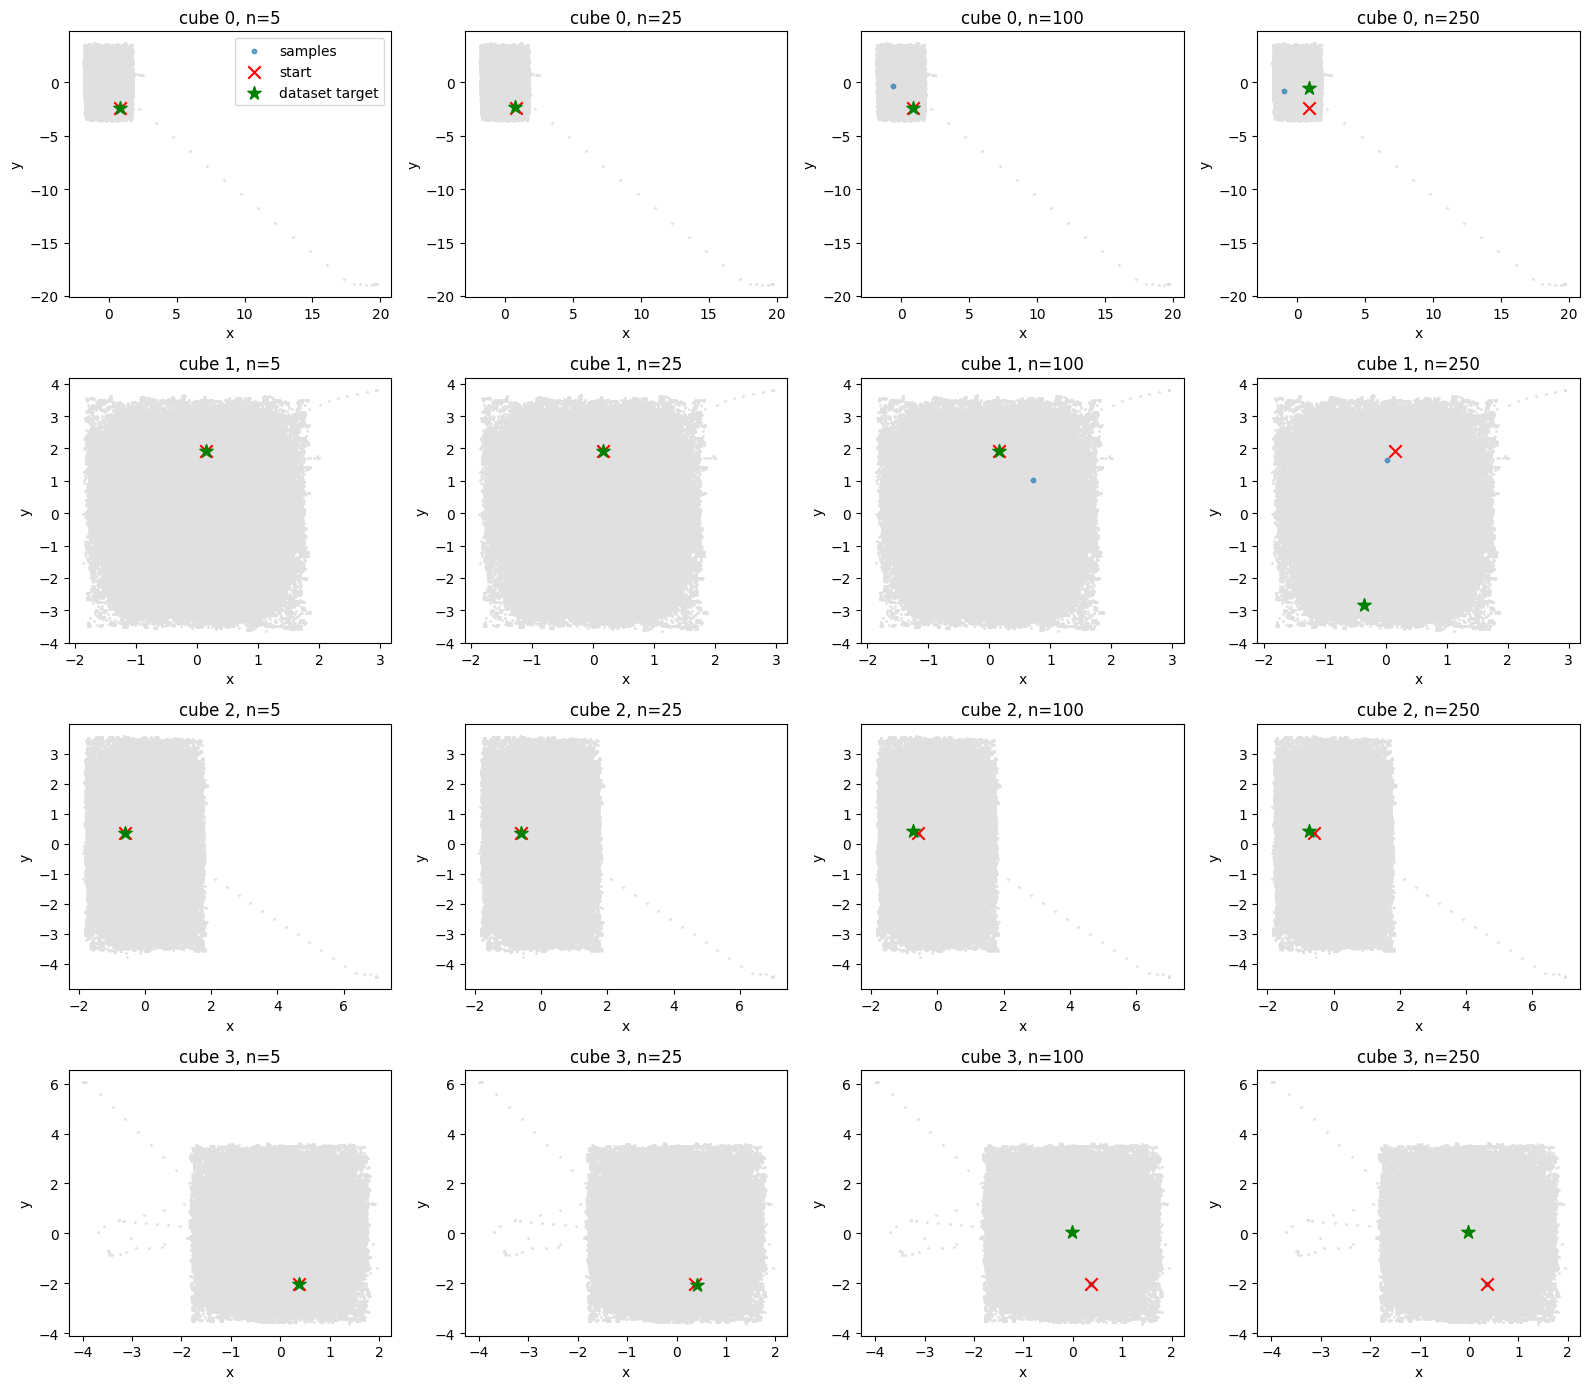

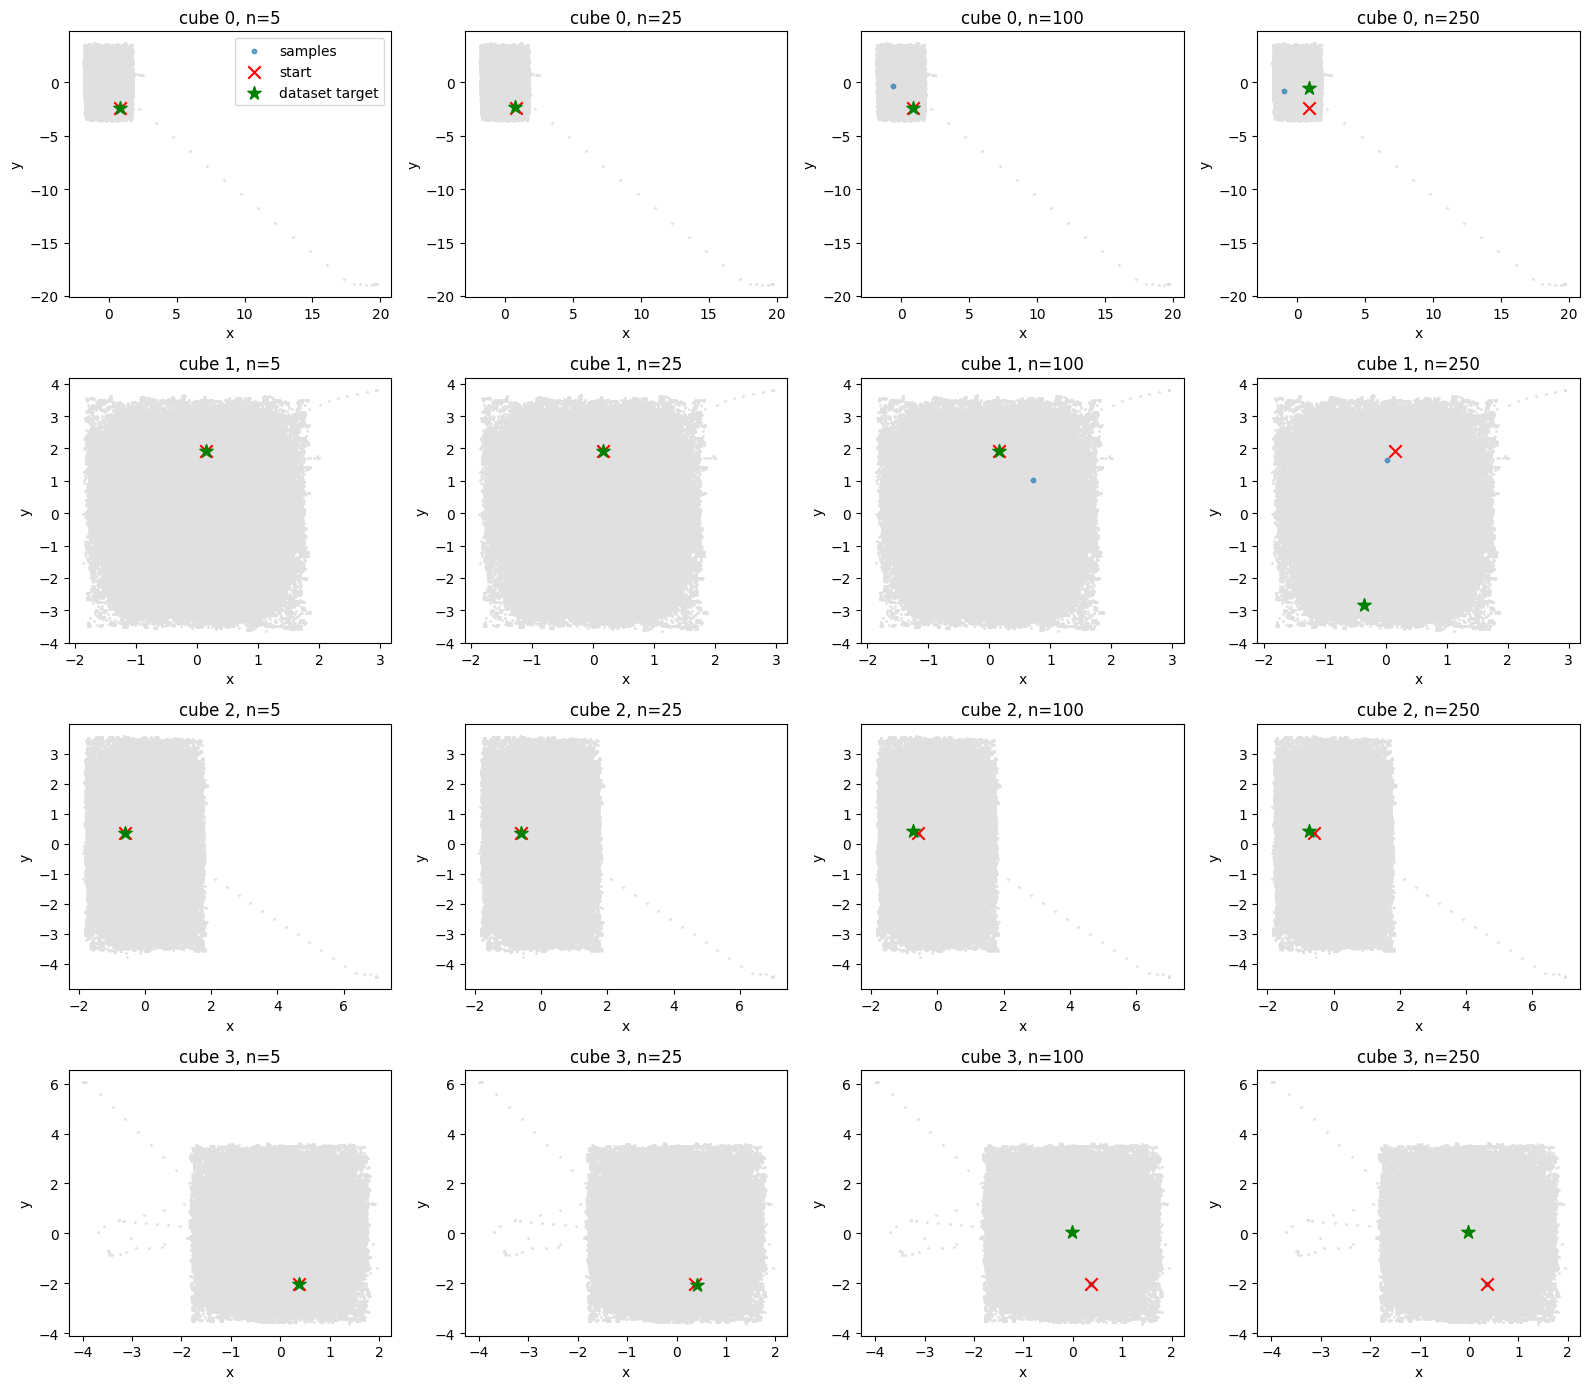

In [25]:
def reshape_cube_reps(reps, num_cubes):
    reps = np.asarray(reps, dtype=np.float32)
    return reps.reshape(reps.shape[0], num_cubes, 3)


all_cube_xyz = reshape_cube_reps(base_train_dataset['oracle_reps'], num_cubes)


def plot_cube_horizon_samples(dataset, agent, idx, horizons=(5, 25, 100, 250), num_samples=128, seed=0):
    idx = int(idx)
    rng = jax.random.PRNGKey(seed)

    observation = np.asarray(dataset.dataset['oracle_reps'][idx], dtype=np.float32)
    final_idx = dataset.terminal_locs[np.searchsorted(dataset.terminal_locs, idx)]
    observation_xyz = observation.reshape(num_cubes, 3)

    fig, axes = plt.subplots(
        num_cubes,
        len(horizons),
        figsize=(4 * len(horizons), 3.5 * num_cubes),
        sharex=False,
        sharey=False,
    )
    if num_cubes == 1:
        axes = np.asarray([axes])
    if len(horizons) == 1:
        axes = axes[:, None]

    for col, horizon in enumerate(horizons):
        target_idx = min(idx + int(horizon), int(final_idx))
        target = np.asarray(dataset.dataset['oracle_reps'][target_idx], dtype=np.float32)
        target_xyz = target.reshape(num_cubes, 3)

        rng, sample_rng = jax.random.split(rng)
        samples = np.asarray(
            agent.sample_actions(
                observations=observation,
                horizons=float(horizon),
                rng=sample_rng,
                num_samples=num_samples,
            )
        )
        samples_xyz = reshape_cube_reps(samples, num_cubes)

        for cube_idx in range(num_cubes):
            ax = axes[cube_idx, col]
            ax.scatter(all_cube_xyz[:, cube_idx, 0], all_cube_xyz[:, cube_idx, 1], s=4, c='0.88', linewidths=0)
            ax.scatter(samples_xyz[:, cube_idx, 0], samples_xyz[:, cube_idx, 1], s=10, alpha=0.65, label='samples')
            ax.scatter(observation_xyz[cube_idx, 0], observation_xyz[cube_idx, 1], marker='x', s=80, c='red', label='start')
            ax.scatter(target_xyz[cube_idx, 0], target_xyz[cube_idx, 1], marker='*', s=100, c='green', label='dataset target')
            ax.set_title(f'cube {cube_idx}, n={int(horizon)}')
            ax.set_xlabel('x')
            ax.set_ylabel('y')

    axes[0, 0].legend(loc='best')
    fig.tight_layout()
    return fig


valid_idx = int(train_dataset.dataset.get_random_idxs(1)[0])
plot_cube_horizon_samples(train_dataset, agent, valid_idx, seed=config['seed'])


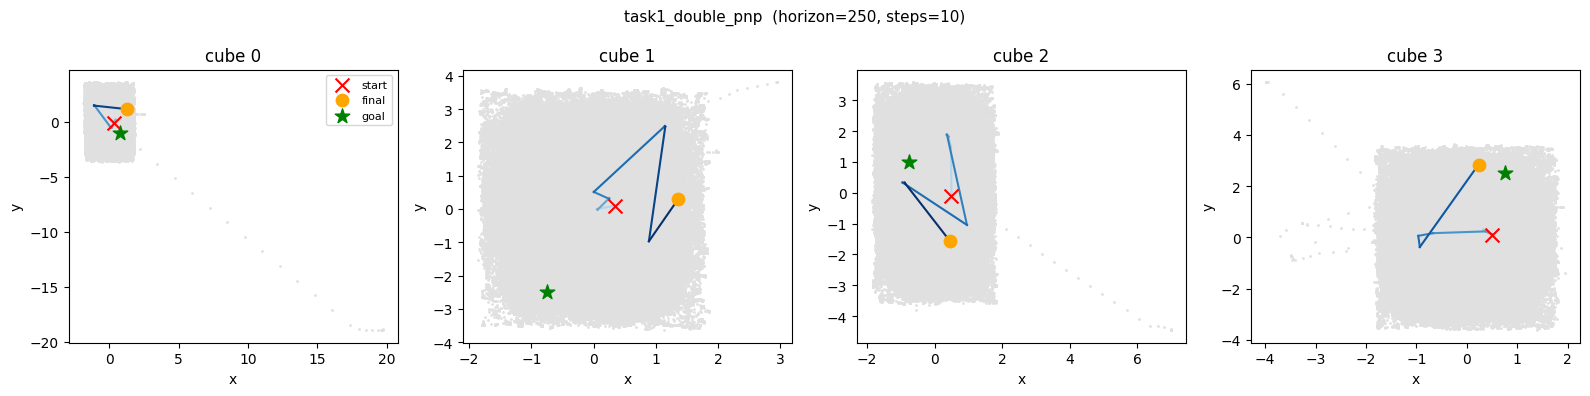

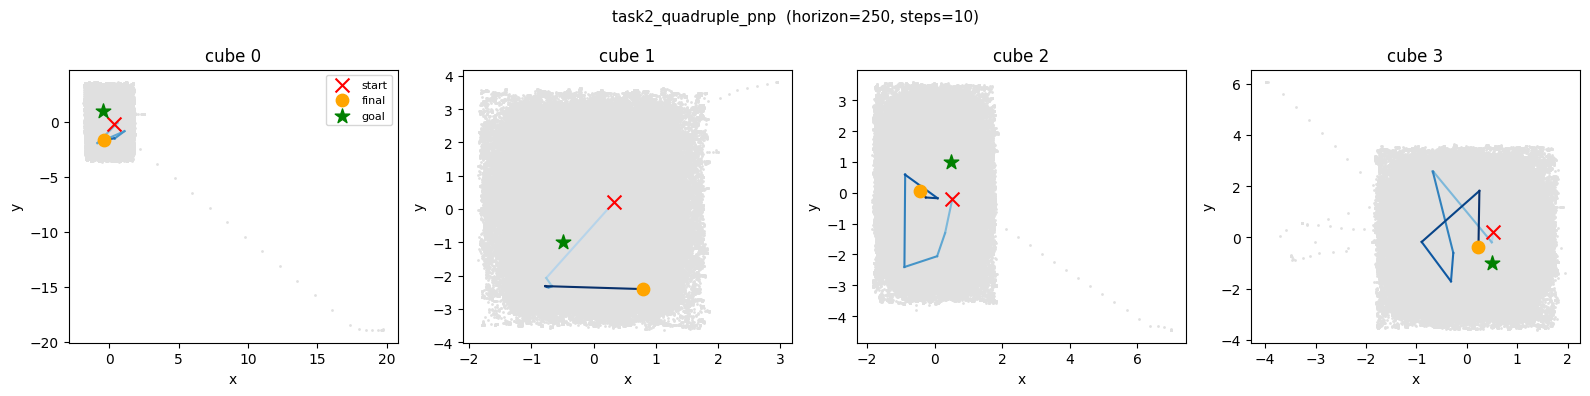

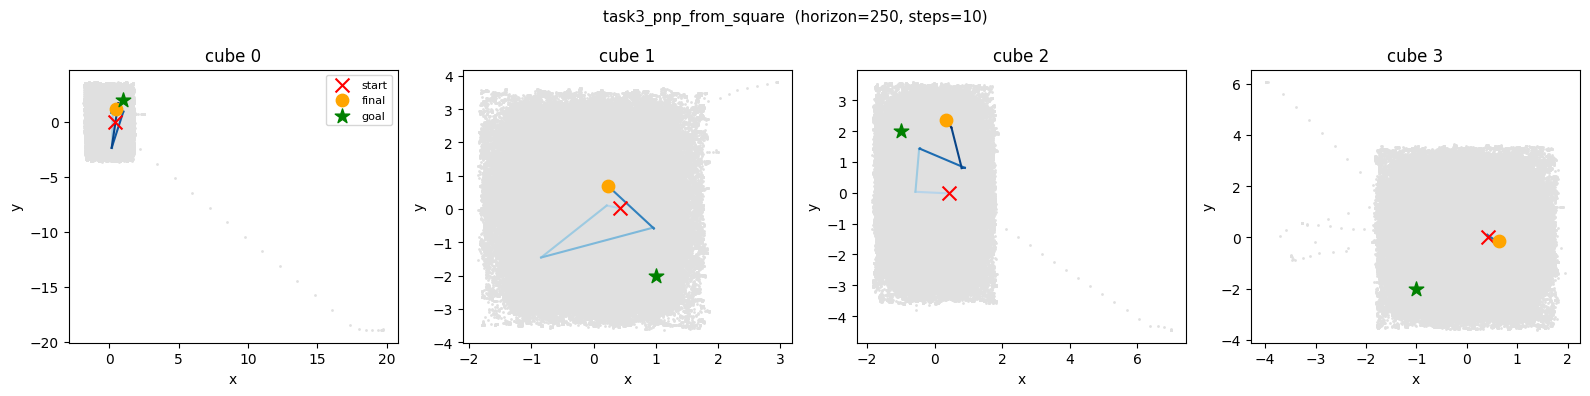

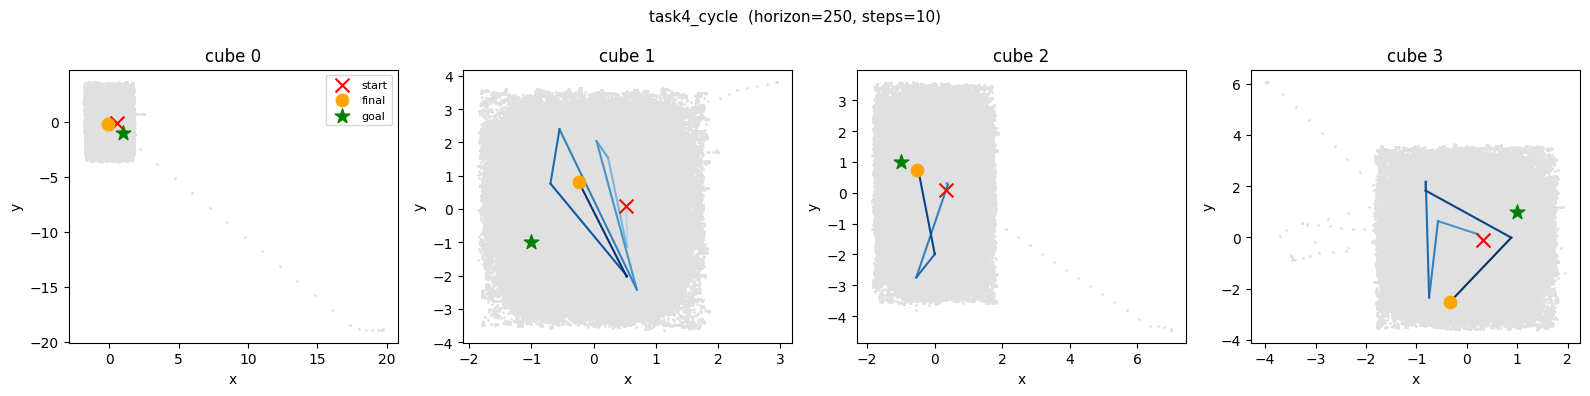

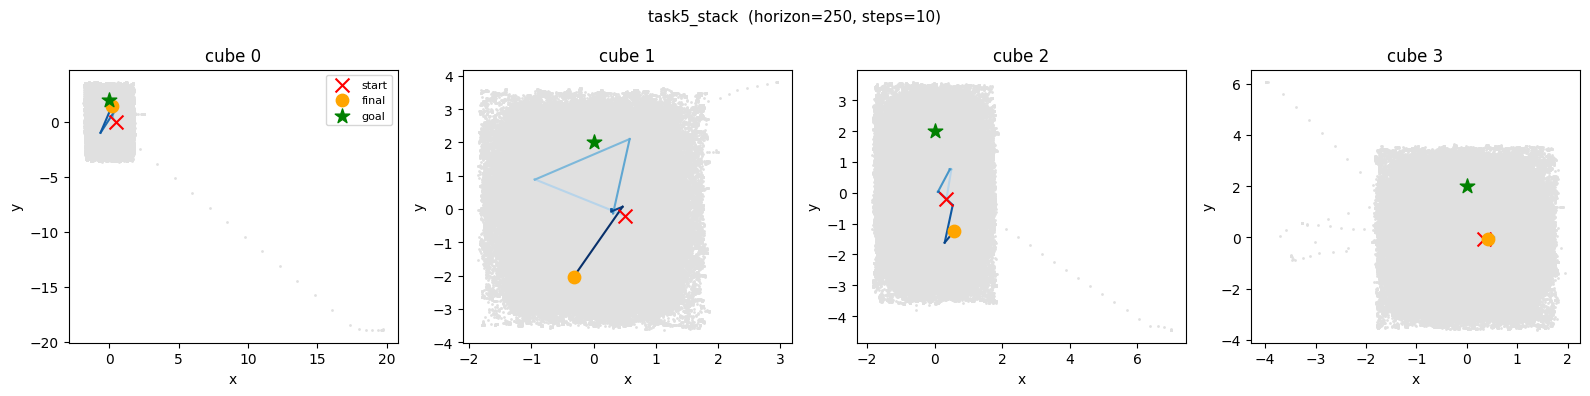

In [26]:
rollout_horizon = config['subgoal_steps']  # horizon for each proposer step
rollout_num_samples = 128                  # subgoals sampled per step
rollout_num_steps = 10                     # chain length
rollout_seed = config['seed']

task_infos = env.unwrapped.task_infos

rng = jax.random.PRNGKey(rollout_seed)
for task_info in task_infos:
    start_oracle = task_info['init_xyzs'].flatten().astype(np.float32)
    ob, info = env.reset(options=dict(task_info=task_info))
    # goal_oracle = to_oracle_reps(info['goal'][None], env=env)[0]
    goal_oracle = info['goal']

    rng, rollout_rng = jax.random.split(rng)
    trajectory = subgoal_rollout(
        agent, start_oracle, goal_oracle,
        horizon=rollout_horizon,
        num_samples=rollout_num_samples,
        num_steps=rollout_num_steps,
        rng=rollout_rng,
    )
    plot_subgoal_rollout(
        trajectory, goal_oracle, all_cube_xyz, num_cubes,
        title=f"{task_info['task_name']}  (horizon={rollout_horizon}, steps={rollout_num_steps})",
    )
    plt.show()


In [27]:
Path(config['output_dir']).mkdir(parents=True, exist_ok=True)
save_agent(agent, config['output_dir'], config['num_train_steps'])


Saved to checkpoints/cube_quadruple_horizon_subgoal_proposer/params_50000.pkl


## Continue training: observation+horizon-conditioned proposer (+1 M steps)

Restore from the 50 k checkpoint and run 1 M additional gradient steps, saving every 100 k steps.

In [28]:
# from utils.flax_utils import restore_agent
# from agents.goal_proposer import latest_checkpoint_step

# EXTRA_STEPS = 1_000_000
# SAVE_INTERVAL = 100_000

# ckpt_step = latest_checkpoint_step(config['output_dir'])
# agent = GCFlowGoalProposerAgent.create(example_batch, config)
# agent = restore_agent(agent, config['output_dir'], ckpt_step)
# print(f'Restored from step {ckpt_step}; training {EXTRA_STEPS} more steps')

# history_continued = dict(flow_loss=[], velocity_mae=[], endpoint_mse=[])
# pbar = trange(1, EXTRA_STEPS + 1)
# for step in pbar:
#     batch = train_dataset.sample(config['batch_size'])
#     agent, info = agent.update(batch)
#     for key in history_continued:
#         history_continued[key].append(float(info[key]))
#     if step % 5_000 == 0:
#         pbar.set_description(
#             f"loss={history_continued['flow_loss'][-1]:.4f} mae={history_continued['velocity_mae'][-1]:.4f}"
#         )
#     if step % SAVE_INTERVAL == 0:
#         global_step = ckpt_step + step
#         save_agent(agent, config['output_dir'], global_step)
#         print(f'  checkpoint at global step {global_step}')

In [29]:
# fig, ax = plt.subplots(figsize=(7, 4))
# ax.plot(history_continued['flow_loss'], label='flow loss', alpha=0.85)
# ax.plot(history_continued['endpoint_mse'], label='endpoint mse', alpha=0.85)
# ax.set_yscale('log')
# ax.set_xlabel('training step (within continuation)')
# ax.set_title(f'conditioned proposer — steps {ckpt_step}→{ckpt_step + EXTRA_STEPS}')
# ax.legend()
# fig.tight_layout()

## Unconditioned (horizon-only) proposer (2 M steps)

Train a proposer with `observation_conditioned=False` — it receives no current-state information, only the encoded horizon length. The network learns a horizon-conditioned marginal distribution over reachable states, ignoring where the agent currently is. Saves every 200 k steps.

In [ ]:
uncond_config = make_goal_proposer_config(
    'cube_quadruple_unconditioned_subgoal_proposer',
    observation_conditioned=False,
    horizon_conditioned=True,
    base_config=base_config,
)
uncond_config.update(
    batch_size=256,
    num_train_steps=2_000_000,
    log_interval=5_000,
    min_horizon_steps=1,
    max_horizon_steps=250,
    subgoal_steps=250,
    horizon_scale=250.0,
    output_dir='checkpoints/cube_quadruple_unconditioned_subgoal_proposer',
)
uncond_config

{'env_name': 'cube-quadruple-play-v0',
 'dataset_path': '../../scratch/data/cube-quadruple-play-v0/cube-quadruple-play-v0.npz',
 'observations_key': 'oracle_reps',
 'goal_key': 'actor_goals',
 'hidden_dims': (256, 256, 256),
 'layer_norm': True,
 'lr': 0.0003,
 'flow_steps': 10,
 'discount': 0.995,
 'backup_horizon': 25,
 'seed': 0,
 'output_dir': 'checkpoints/cube_quadruple_unconditioned_subgoal_proposer',
 'num_train_steps': 2000000,
 'batch_size': 256,
 'log_interval': 5000,
 'actions_key': 'low_actor_goals',
 'value_p_curgoal': 0.0,
 'value_p_trajgoal': 1.0,
 'value_p_randomgoal': 0.0,
 'value_geom_sample': False,
 'actor_p_curgoal': 0.0,
 'actor_p_trajgoal': 1.0,
 'actor_p_randomgoal': 0.0,
 'actor_geom_sample': True,
 'gc_negative': False,
 'goal_conditioned': False,
 'observation_conditioned': False,
 'horizon_conditioned': True,
 'horizon_key': 'horizons',
 'min_horizon_steps': 1,
 'max_horizon_steps': 250,
 'subgoal_steps': 250,
 'horizon_scale': 250.0}

In [ ]:
UNCOND_SAVE_INTERVAL = 200_000

from pathlib import Path
Path(uncond_config['output_dir']).mkdir(parents=True, exist_ok=True)

uncond_agent = GCFlowGoalProposerAgent.create(example_batch, uncond_config)
history_uncond = dict(flow_loss=[], velocity_mae=[], endpoint_mse=[])

pbar = trange(1, uncond_config['num_train_steps'] + 1)
for step in pbar:
    batch = train_dataset.sample(uncond_config['batch_size'])
    uncond_agent, info = uncond_agent.update(batch)
    for key in history_uncond:
        history_uncond[key].append(float(info[key]))
    if step % 5_000 == 0:
        pbar.set_description(
            f"loss={history_uncond['flow_loss'][-1]:.4f} mae={history_uncond['velocity_mae'][-1]:.4f}"
        )
    if step % UNCOND_SAVE_INTERVAL == 0:
        save_agent(uncond_agent, uncond_config['output_dir'], step)
        print(f'  checkpoint at step {step}')

save_agent(uncond_agent, uncond_config['output_dir'], uncond_config['num_train_steps'])
print(f'Saved final unconditioned proposer to {uncond_config["output_dir"]}')

loss=1.4059 mae=0.8496:  10%|█         | 200018/2000000 [31:09<4:43:00, 106.00it/s]

Saved to checkpoints/cube_quadruple_unconditioned_subgoal_proposer/params_200000.pkl
  checkpoint at step 200000


loss=1.4414 mae=0.8662:  20%|██        | 400013/2000000 [1:02:16<4:11:10, 106.16it/s]

Saved to checkpoints/cube_quadruple_unconditioned_subgoal_proposer/params_400000.pkl
  checkpoint at step 400000


loss=1.3876 mae=0.8368:  30%|███       | 600017/2000000 [1:33:26<3:43:33, 104.37it/s]

...

Saved to checkpoints/cube_quadruple_unconditioned_subgoal_proposer/params_1600000.pkl
  checkpoint at step 1600000


loss=1.3567 mae=0.8192:  90%|█████████ | 1800018/2000000 [4:40:24<31:14, 106.66it/s]  

Saved to checkpoints/cube_quadruple_unconditioned_subgoal_proposer/params_1800000.pkl
  checkpoint at step 1800000


loss=1.3482 mae=0.8363: 100%|██████████| 2000000/2000000 [5:11:34<00:00, 106.98it/s]

Saved to checkpoints/cube_quadruple_unconditioned_subgoal_proposer/params_2000000.pkl
  checkpoint at step 2000000
Saved to checkpoints/cube_quadruple_unconditioned_subgoal_proposer/params_2000000.pkl
Saved final unconditioned proposer to checkpoints/cube_quadruple_unconditioned_subgoal_proposer


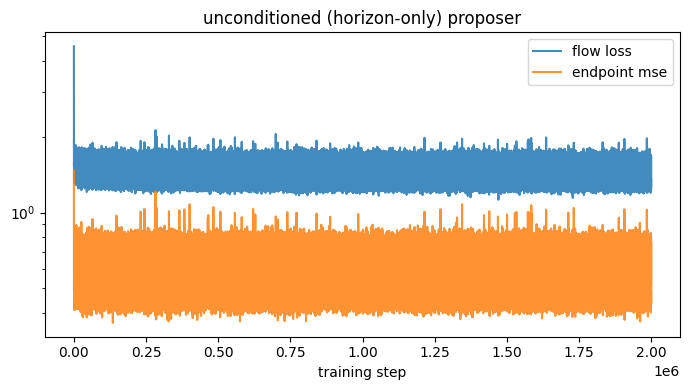

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history_uncond['flow_loss'], label='flow loss', alpha=0.85)
ax.plot(history_uncond['endpoint_mse'], label='endpoint mse', alpha=0.85)
ax.set_yscale('log')
ax.set_xlabel('training step')
ax.set_title('unconditioned (horizon-only) proposer')
ax.legend()
fig.tight_layout()

## Rollout comparison

Greedy subgoal chains (length 10, 128 candidates per step) for both proposers across all tasks. At each step the candidate closest in L2 oracle space to the task goal is selected as the next waypoint.

In [ ]:
rollout_horizon = config['subgoal_steps']
rollout_num_samples = 128
rollout_num_steps = 10

rng = jax.random.PRNGKey(42)
for task_info in task_infos:
    start_oracle = task_info['init_xyzs'].flatten().astype(np.float32)
    _, info = env.reset(options=dict(task_info=task_info))
    goal_oracle = to_oracle_reps(info['goal'][None], env=env)[0]
    task_name = task_info['task_name']

    rng, rng_cond, rng_uncond = jax.random.split(rng, 3)

    traj_cond = subgoal_rollout(
        agent, start_oracle, goal_oracle,
        horizon=rollout_horizon, num_samples=rollout_num_samples,
        num_steps=rollout_num_steps, rng=rng_cond,
    )
    traj_uncond = subgoal_rollout(
        uncond_agent, start_oracle, goal_oracle,
        horizon=rollout_horizon, num_samples=rollout_num_samples,
        num_steps=rollout_num_steps, rng=rng_uncond,
    )

    plot_subgoal_rollout(
        traj_cond, goal_oracle, all_cube_xyz, num_cubes,
        title=f'{task_name} — obs+horizon-conditioned (step {ckpt_step + EXTRA_STEPS})',
    )
    plt.show()

    plot_subgoal_rollout(
        traj_uncond, goal_oracle, all_cube_xyz, num_cubes,
        title=f'{task_name} — unconditioned / horizon-only (step {uncond_config["num_train_steps"]})',
    )
    plt.show()


## How reachable are the proposed subgoals?

### Restore subgoal proposer checkpoints

In [ ]:
from utils.flax_utils import restore_agent
from agents.goal_proposer import latest_checkpoint_step

/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


In [ ]:
cond_ckpt_step = latest_checkpoint_step(config['output_dir'])
agent = GCFlowGoalProposerAgent.create(example_batch, config)
agent = restore_agent(agent, config['output_dir'], cond_ckpt_step)
print(f'Restored obs+horizon-conditioned agent from step {cond_ckpt_step}')

uncond_ckpt_step = latest_checkpoint_step(uncond_config['output_dir'])
uncond_agent = GCFlowGoalProposerAgent.create(example_batch, uncond_config)
uncond_agent = restore_agent(uncond_agent, uncond_config['output_dir'], uncond_ckpt_step)
print(f'Restored horizon-only unconditioned agent from step {uncond_ckpt_step}')

Restored from checkpoints/cube_quadruple_horizon_subgoal_proposer/params_1050000.pkl
Restored obs+horizon-conditioned agent from step 1050000
Restored from checkpoints/cube_quadruple_unconditioned_subgoal_proposer/params_2000000.pkl
Restored horizon-only unconditioned agent from step 2000000


### Create the cube environment

In [ ]:
env, base_train_dataset, val_dataset = make_env_and_datasets(
    config['env_name'],
    dataset_path=base_config['dataset_path'],
    use_oracle_reps=True,
)
num_cubes = int(env.unwrapped._num_cubes)
task_infos = env.unwrapped.task_infos
print('env:', env.spec.id)
print('num_cubes:', num_cubes)
print('num_tasks:', len(task_infos))

env: cube-quadruple-v0
num_cubes: 4
num_tasks: 5


### Restoring trained DQC agent

In [ ]:
import json
from agents import agents as agent_registry
from utils.datasets import CGCDataset

DQC_PATH = '../../scratch/dqc-reproduce/sd100001s_33728300.0.33728299.1.20260425_014426/'
DQC_CKPT = 1_000_000

with open(f'{DQC_PATH}/flags.json') as f:
    dqc_flags = json.load(f)
dqc_agent_config = dqc_flags['agent']

In [ ]:
# placeholder values
dqc_agent_config['actor_p_curgoal'] = 0.5
dqc_agent_config['actor_p_trajgoal'] = 0.5
dqc_agent_config['actor_p_randomgoal'] = 0.0
dqc_agent_config['actor_geom_sample'] = 0.5
dqc_agent_config['subgoal_steps'] = 100
dqc_agent_config['train_goal_proposer'] = False


In [ ]:
dqc_dataset = CGCDataset(base_train_dataset, config=dqc_agent_config)
dqc_example_batch = dqc_dataset.sample(1)

dqc_agent = agent_registry[dqc_agent_config['agent_name']].create(
    base_config['seed'], dqc_example_batch, dqc_agent_config,
)
dqc_agent = restore_agent(dqc_agent, DQC_PATH, DQC_CKPT)
print(f'Restored DQC agent from step {DQC_CKPT}')

Restored from ../../scratch/dqc-reproduce/sd100001s_33728300.0.33728299.1.20260425_014426//params_1000000.pkl
Restored DQC agent from step 1000000


## Testing reachabilitiy

In [ ]:
observation, _ = env.reset()
print(observation)

[-2.03785733 -1.5546051   1.68420073 -1.70039195 -1.57079633 -1.03876544
  0.          0.          0.          0.          0.          0.
  0.7784879  -1.03500038  2.8148489   0.84097998  0.54106624  0.
  0.          0.96471305  2.02739777  0.2         0.99957205  0.
  0.          0.02925255  0.99828858  0.05848005 -1.09381696  2.06600486
  0.2        -0.0281449   0.          0.          0.99960385 -0.99841573
 -0.0562675  -0.97853869 -1.91189355  0.2         0.63661415  0.
  0.          0.77118248 -0.18944485  0.98189136  1.05118505 -1.92012177
  0.2         0.88908057  0.          0.          0.45775074  0.58092852
  0.81395458]


In [ ]:
horizon = 100
num_samples = 128

In [ ]:
rng = jax.random.PRNGKey(1001)
sample_rng, rng = jax.random.split(rng)

In [ ]:
from wrappers.datafuncs_utils import make_env_and_datasets, to_oracle_reps

oracle_rep = to_oracle_reps(observation[None], env=env)

In [ ]:
samples = np.asarray(
            agent.sample_actions(
                observations=np.repeat(oracle_rep, 128, axis=0),
                horizons=float(horizon),
                rng=sample_rng,
                num_samples=num_samples,
            )
        )

In [ ]:
samples.shape

(128, 12)

In [ ]:
env.cur_task_info

/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.cur_task_info to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.cur_task_info` for environment variables or `env.get_wrapper_attr('cur_task_info')` that will search the reminding wrappers.
  logger.warn(


{'task_name': 'task5_stack',
 'init_xyzs': array([[ 0.5 , -0.05,  0.02],
        [ 0.5 , -0.2 ,  0.02],
        [ 0.35, -0.2 ,  0.02],
        [ 0.35, -0.05,  0.02]]),
 'goal_xyzs': array([[0.425, 0.2  , 0.02 ],
        [0.425, 0.2  , 0.06 ],
        [0.425, 0.2  , 0.1  ],
        [0.425, 0.2  , 0.14 ]])}

In [ ]:
temp_ob, _ = env.reset(options=dict(
    task_info=env.cur_task_info
))
print(temp_ob.shape)
print(temp_ob)
# print(to_oracle_reps(temp_ob[None], env=env)[0])

(55,)
[-1.69454522 -1.66308765  1.98495381 -1.89266249 -1.57079633 -0.26348104
  0.          0.          0.          0.          0.          0.
  0.20932503  0.7956553   2.06387001  0.99025334  0.13927787  0.
  0.          0.09230673 -0.10506885  0.2         0.95307273  0.
  0.          0.30274143  0.81669525  0.57706921 -0.01868383  0.18276241
  0.6        -0.68921661  0.          0.          0.72455536 -0.04996094
 -0.99875117  0.03573246 -0.17308005  0.6        -0.5648719   0.
  0.          0.82517861 -0.36183947 -0.93224042 -0.0023047   0.14879541
  0.2         0.98005193  0.          0.          0.1987416   0.92100355
  0.38955417]


In [ ]:
from tqdm import tqdm

In [ ]:
ob, _ = env.reset(options=dict(
        task_info=env.cur_task_info
    ))
oracle_rep = to_oracle_reps(ob[None], env=env)

sample_rng, rng = jax.random.split(rng)
samples = np.asarray(
            agent.sample_actions(
                observations=np.repeat(oracle_rep, 128, axis=0),
                horizons=float(horizon),
                rng=sample_rng,
                num_samples=num_samples,
            )
        )

replay_buffers = []

for subgoal in samples:
    replay_buffer = []
    ob, _ = env.reset(options=dict(
        task_info=env.cur_task_info
    ))
    for step in tqdm(range(200)):
        action_rng, rng = jax.random.split(rng)
        action = dqc_agent.sample_actions(
            observations=ob,
            goals=subgoal,
            seed=action_rng
        )
        for a in action:
            ob, reward, terminated, truncated, _ = env.step(a)
            replay_buffer.append(ob)

            # if np.linalg.norm(ob - subgoal) < 
            oracle_rep = to_oracle_reps(ob[None], env=env)
            if np.linalg.norm(oracle_rep - subgoal, axis=-1) <= 0.04:
                print('finished')
                break

    replay_buffers.append(replay_buffer)

/home/jennifer/miniconda3/envs/aorl/lib/python3.10/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.cur_task_info to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.cur_task_info` for environment variables or `env.get_wrapper_attr('cur_task_info')` that will search the reminding wrappers.
  logger.warn(
 88%|████████▊ | 176/200 [00:24<00:03,  7.08it/s]


KeyboardInterrupt: 

## Testing goal-reaching abilities

## DQC Value Function Visualization

For each task: reset the environment to the start state, then sweep each cube's XY position over a grid while holding the other three cubes at their goal positions.  The heatmap shows `sigmoid(V(obs, goal))` — the value the DQC assigns to reaching that goal from the start observation.

In [ ]:
import jax.numpy as jnp

XYZ_CENTER  = np.array([0.425, 0.0, 0.0], dtype=np.float32)
XYZ_SCALER  = 10.0
Z_FIXED     = 0.02   # near-table height used when sweeping XY
GRID_SIZE   = 40


def xyzs_to_oracle(xyzs):
    """(num_cubes, 3) → flat 12-dim oracle rep."""
    return ((np.asarray(xyzs, dtype=np.float32) - XYZ_CENTER) * XYZ_SCALER).reshape(-1)


def plot_dqc_value_heatmap(dqc_agent, env, task_info, all_cube_xyz, num_cubes,
                            grid_size=GRID_SIZE, title=''):
    ob, info = env.reset(options=dict(task_info=task_info))
    goal_oracle = to_oracle_reps(info['goal'][None], env=env)[0]
    goal_xyzs = (goal_oracle.reshape(num_cubes, 3) / XYZ_SCALER + XYZ_CENTER)
    init_xyzs = np.asarray(task_info['init_xyzs'], dtype=np.float32)

    fig, axes = plt.subplots(1, num_cubes, figsize=(4 * num_cubes, 4), squeeze=False)
    axes = axes[0]

    for cube_idx in range(num_cubes):
        ax = axes[cube_idx]

        # Grid over this cube's XY range in the dataset
        xs = all_cube_xyz[:, cube_idx, 0]
        ys = all_cube_xyz[:, cube_idx, 1]
        x_grid = np.linspace(xs.min(), xs.max(), grid_size)
        y_grid = np.linspace(ys.min(), ys.max(), grid_size)
        xx, yy = np.meshgrid(x_grid, y_grid)

        # Build oracle rep goals: other cubes fixed at their goal positions
        swept_xyzs = np.tile(goal_xyzs[None], (grid_size * grid_size, 1, 1))  # (N, 4, 3)
        swept_xyzs[:, cube_idx, 0] = xx.ravel()
        swept_xyzs[:, cube_idx, 1] = yy.ravel()
        swept_xyzs[:, cube_idx, 2] = Z_FIXED
        grid_goals = ((swept_xyzs - XYZ_CENTER) * XYZ_SCALER).reshape(-1, num_cubes * 3)

        # Evaluate value in one batched call
        obs_batch = np.repeat(ob[None], len(grid_goals), axis=0)
        v_logits  = np.asarray(dqc_agent.network.select('value')(obs_batch, goals=grid_goals))
        v_values  = jax.nn.sigmoid(v_logits).reshape(grid_size, grid_size)

        im = ax.imshow(
            np.asarray(v_values), origin='lower',
            extent=[x_grid[0], x_grid[-1], y_grid[0], y_grid[-1]],
            aspect='auto', cmap='viridis',
        )
        ax.scatter(all_cube_xyz[:, cube_idx, 0], all_cube_xyz[:, cube_idx, 1],
                   s=2, c='white', alpha=0.15, linewidths=0)
        ax.scatter(*init_xyzs[cube_idx, :2], marker='x', s=100, c='red',   zorder=5, label='start')
        ax.scatter(*goal_xyzs[cube_idx, :2], marker='*', s=140, c='lime',  zorder=5, label='goal')
        ax.set_title(f'cube {cube_idx}')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        plt.colorbar(im, ax=ax, label='V')

    axes[0].legend(loc='best', fontsize=8)
    if title:
        fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    return fig


for task_info in task_infos:
    fig = plot_dqc_value_heatmap(
        dqc_agent, env, task_info, all_cube_xyz, num_cubes,
        title=f"DQC value — {task_info['task_name']}",
    )
    plt.show()
